# Chapter 16 - Underfitting and overfitting

*This notebook contains all the sample code in Chapter 16.*

## Outline

- [Diagnosing underfitting and overfitting](#Diagnosing)
    - [Learning curves](#Learning_curves)
    - [Validation curves](#Validation_curves)
    - [Early stopping](#Early_stopping)
- [Information criteria for model selection](#Information)
- [Random forests](#Random_forests)
- [Boosting](#Boosting)
    - [AdaBoost](#AdaBoost)
    - [Gradient boosting](#Gradient_boosting)
- [Stacking](#Stacking)
- [Ensemble methods for regression](#Regression)

## Diagnosing underfitting and overfitting <a id="Diagnosing"></a>

Training and validation performance should be examined together. For a score that must be maximized, such as accuracy, the following patterns are typical:
- **Underfitting**: both the training and validation scores are low and relatively close;
- **Overfitting**: the training score is high, whereas the validation score is substantially lower;
- **Good generalization**: both scores are high and their difference is limited.

For a loss that must be minimized, the interpretation is reversed: underfitting produces high training and validation losses, whereas overfitting produces a low training loss and a noticeably higher validation loss.

> Learning curves, validation curves, early stopping, and hyperparameter selection must use training and validation data only. The test set should remain untouched until the complete model-selection procedure has finished, otherwise the reported test performance may become optimistically biased.

### Learning curves <a id="Learning_curves"></a>

A **learning curve** shows the training and cross-validation scores as functions of the number of training samples. It helps determine whether collecting more data is likely to improve the model and whether the dominant problem is high bias or high variance.

The following example evaluates logistic regression on the Wisconsin breast-cancer dataset. The test set is separated first and is not used to construct the curves.

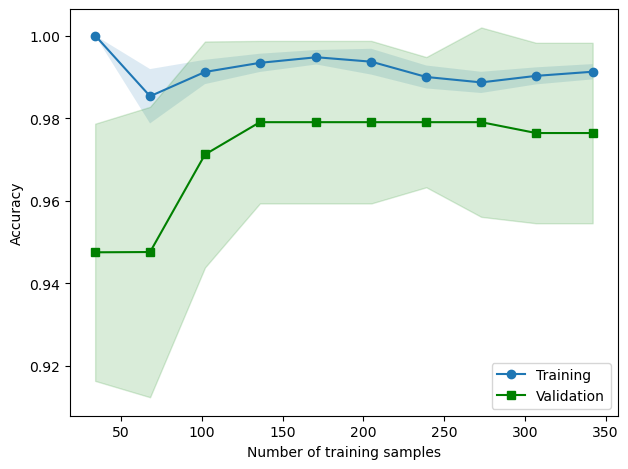

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    stratify=y,
    random_state=1,
)

pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=1),
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

plt.plot(train_sizes, train_mean, marker='o', label='Training')
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
)
plt.plot(train_sizes, valid_mean, color='green', marker='s', label='Validation')
plt.fill_between(
    train_sizes,
    valid_mean - valid_std,
    valid_mean + valid_std,
    alpha=0.15,
    color="green",
)
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Scikit-learn also provides the `LearningCurveDisplay` class, which directly computes and plots the curves:

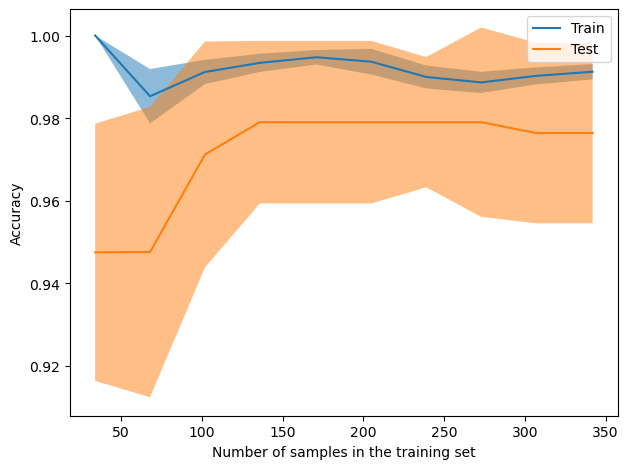

In [2]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    pipe,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    score_name='Accuracy',
)
plt.tight_layout()
plt.show()

### Validation curves <a id="Validation_curves"></a>

A **validation curve** shows the training and cross-validation scores obtained while varying one hyperparameter. It is particularly useful for visualizing how that hyperparameter controls model complexity.

For logistic regression with $\ell_2$ regularization, the parameter $C$ is the inverse of the regularization strength. Small values of $C$ impose stronger regularization and may produce underfitting. Large values reduce regularization and may increase variance.

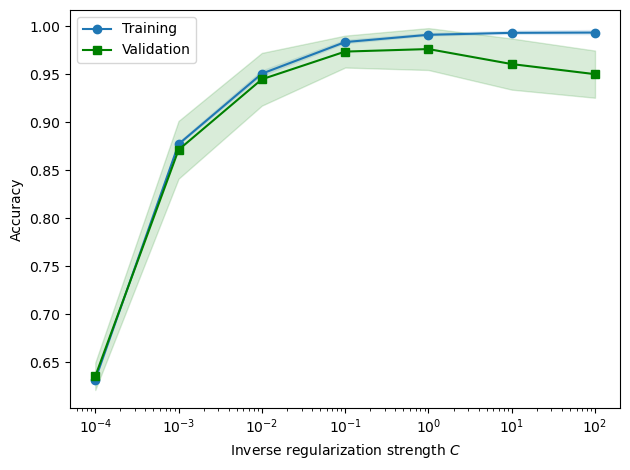

In [3]:
from sklearn.model_selection import validation_curve

param_range = np.logspace(-4, 2, 7)

train_scores, valid_scores = validation_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

plt.semilogx(param_range, train_mean, marker='o', label='Training')
plt.fill_between(
    param_range,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
)
plt.semilogx(param_range, valid_mean, color='green', marker='s', label='Validation')
plt.fill_between(
    param_range,
    valid_mean - valid_std,
    valid_mean + valid_std,
    alpha=0.15,
    color="green",
)
plt.xlabel(r'Inverse regularization strength $C$')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Recent versions of Scikit-learn also provide `ValidationCurveDisplay`:

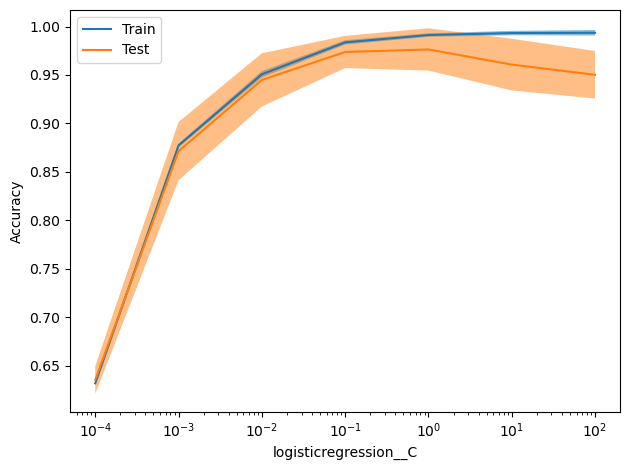

In [4]:
from sklearn.model_selection import ValidationCurveDisplay

ValidationCurveDisplay.from_estimator(
    pipe,
    X_train,
    y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    score_name='Accuracy',
)
plt.tight_layout()
plt.show()

### Early stopping <a id="Early_stopping"></a>

For iterative learning algorithms, training and validation performance can be monitored as functions of the number of iterations or **epochs**. During the first part of training, both typically improve. After a certain point, the training loss may continue to decrease while the validation performance stops improving or begins to deteriorate. This behavior indicates that the model is increasingly fitting training-specific details.

**Early stopping** terminates training when the validation metric has failed to improve sufficiently for a specified number of epochs. The minimum required improvement is often controlled by a tolerance parameter, while the number of consecutive non-improving epochs is called the *patience*.

Several Scikit-learn estimators implement early stopping internally. For `MLPClassifier`, setting `early_stopping=True` reserves a fraction of the training data for validation. Training stops when the validation score fails to improve by at least `tol` for `n_iter_no_change` consecutive epochs. This last parameter is known as *patience* in other contexts.

Stopped after 27 epochs
Best validation accuracy: 0.931
Test accuracy: 0.888


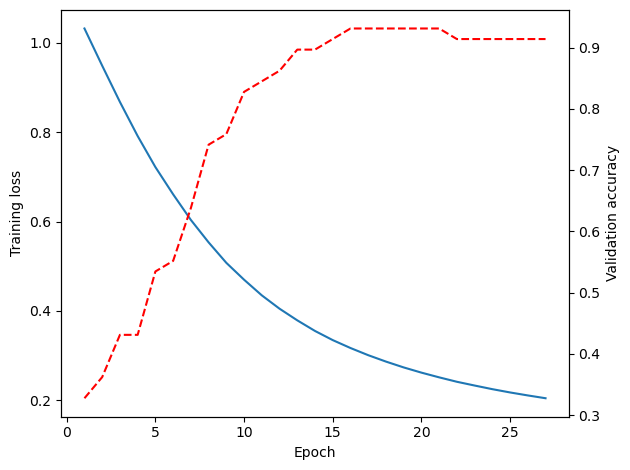

In [5]:
from sklearn.neural_network import MLPClassifier

mlp_pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(50,),
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        tol=1e-4,
        random_state=1,
    ),
)

mlp_pipe.fit(X_train, y_train)
mlp = mlp_pipe.named_steps['mlpclassifier']

print(f'Stopped after {mlp.n_iter_} epochs')
print(f'Best validation accuracy: {mlp.best_validation_score_:.3f}')
print(f'Test accuracy: {mlp_pipe.score(X_test, y_test):.3f}')

epochs = np.arange(1, mlp.n_iter_ + 1)

fig, ax1 = plt.subplots()
ax1.plot(epochs, mlp.loss_curve_)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training loss')

ax2 = ax1.twinx()
ax2.plot(epochs, mlp.validation_scores_, ls='--', color='red')
ax2.set_ylabel('Validation accuracy')

fig.tight_layout()
plt.show()

## Information criteria for model selection <a id="Information"></a>

The problem of underfitting and overfitting can also be addressed through *information criteria*, which balance the quality of the fit against model complexity. Two widely used criteria are the **Akaike information criterion**} (AIC) and the **Bayesian information criterion** (BIC).

Let $\widehat{L}$ denote the maximum value of the likelihood function for a fitted model, $k$ the number of estimated parameters, and $N$ the number of observations. The AIC is defined as:
$$
\mathrm{AIC} = -2\log \widehat{L} + 2k,
$$
whereas the BIC is:
$$
\mathrm{BIC} = -2\log \widehat{L} + k\log N.
$$
In both cases, the first term rewards models that fit the data well, whereas the second penalizes model complexity. Models with smaller values of AIC or BIC are preferred among the candidate models being compared.

AIC and BIC should be used to compare models fitted to the same data and based on comparable likelihood functions. Their absolute values have little meaning by themselves; the differences between candidate models are what matter. Moreover, these criteria do not completely replace validation or cross-validation, especially in machine-learning problems where the main objective is prediction on unseen data. Instead, they provide a complementary statistical tool for understanding and controlling model complexity. As a simple example, we consider polynomial regression models of increasing degree:

Best degree according to AIC: 3
Best degree according to BIC: 3


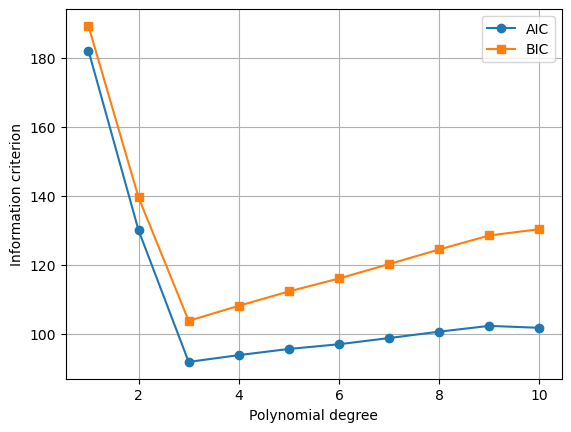

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate a nonlinear dataset
rng = np.random.default_rng(1)
N = 80
X = np.linspace(-3, 3, N).reshape(-1, 1)
x = X[:, 0]

y = 1.0 + 1.5*x - 0.8*x**2 + 0.35*x**3 + rng.normal(0, 2.0, size=N)

degrees = range(1, 11)
aic_values = []
bic_values = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    rss = np.sum((y - y_pred)**2)

    # d+1 regression coefficients plus noise variance
    k = degree + 2

    aic = N * np.log(rss / N) + 2 * k
    bic = N * np.log(rss / N) + k * np.log(N)
    aic_values.append(aic)
    bic_values.append(bic)

best_aic = degrees[np.argmin(aic_values)]
best_bic = degrees[np.argmin(bic_values)]

print("Best degree according to AIC:", best_aic)
print("Best degree according to BIC:", best_bic)

# Plot the criteria
plt.figure()
plt.plot(degrees, aic_values, 'o-', label='AIC')
plt.plot(degrees, bic_values, 's-', label='BIC')

plt.xlabel('Polynomial degree')
plt.ylabel('Information criterion')
plt.legend()
plt.grid()
plt.show()